In [29]:
#  Importing modules and  function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, chi2
from arch import arch_model
from pandas_datareader import data as pdr
import datetime

plt.style.use("seaborn-v0_8")


In [30]:
# Taking user inputs

tickers = ["AAPL", "MSFT"]
weights = np.array([0.5, 0.5])
weights = weights / weights.sum()

confidence = 0.95
rolling_window = 250
mc_sims = 10000
stress_shock = 0.05
garch_dist = "normal"

start_date = datetime.datetime(2020, 1, 1)
end_date = datetime.datetime(2025, 1, 1)


In [31]:
# Data Fetching
tickers_stooq = [t + ".US" for t in tickers]

price_data = pdr.get_data_stooq(
    tickers_stooq,
    start=start_date,
    end=end_date
)["Close"].dropna()

returns = price_data.pct_change().dropna()
portfolio_returns = returns @ weights

price_data.tail()


Symbols,AAPL.US,MSFT.US
Date,,
2020-01-08,73.4042,153.142
2020-01-07,72.2432,150.710
2020-01-06,72.5811,152.118
2020-01-03,72.0115,151.726
2020-01-02,72.7161,153.613


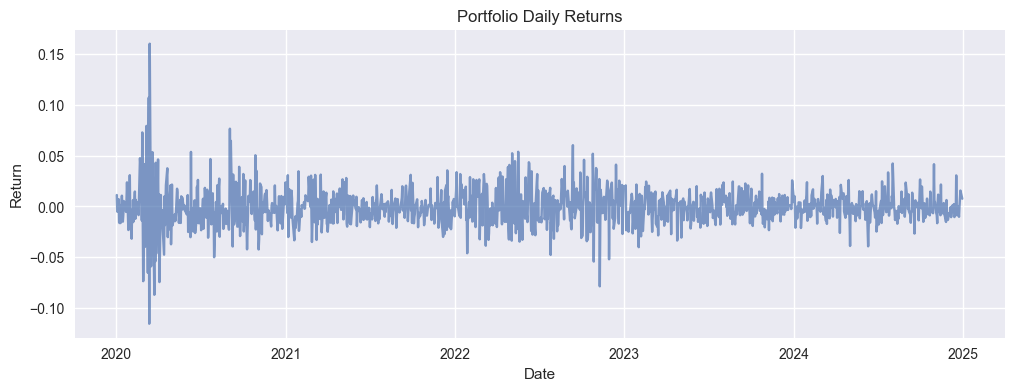

In [32]:
# Plots for daily returns of the portfolio
plt.figure(figsize=(12,4))
plt.plot(portfolio_returns, alpha=0.7)
plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()


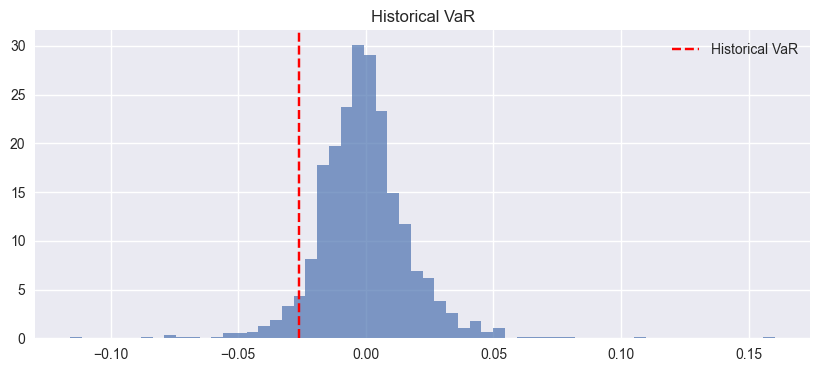

np.float64(-0.026323382863899673)

In [33]:
# Historical VaR
historical_var = np.percentile(
    portfolio_returns,
    (1 - confidence) * 100
)

plt.figure(figsize=(10,4))
plt.hist(portfolio_returns, bins=60, density=True, alpha=0.7)
plt.axvline(historical_var, color="red", linestyle="--", label="Historical VaR")
plt.title("Historical VaR")
plt.legend()
plt.show()

historical_var


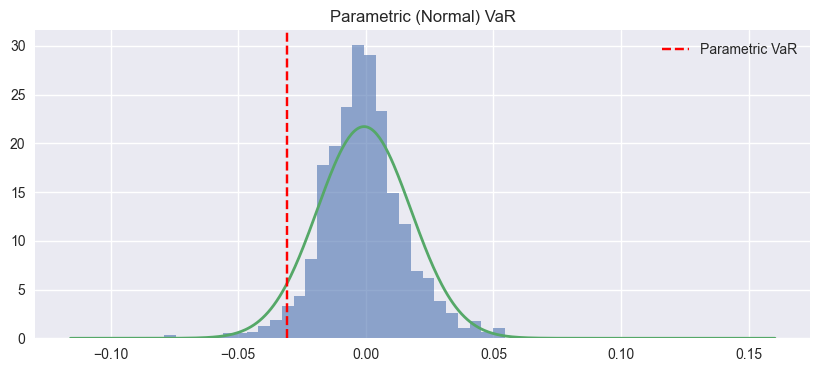

np.float64(-0.030923898265470495)

In [34]:
# Parametric VaR - Normal
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

parametric_var = mean_return + norm.ppf(1 - confidence) * std_return

x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 500)
pdf = norm.pdf(x, mean_return, std_return)

plt.figure(figsize=(10,4))
plt.hist(portfolio_returns, bins=60, density=True, alpha=0.6)
plt.plot(x, pdf, linewidth=2)
plt.axvline(parametric_var, color="red", linestyle="--", label="Parametric VaR")
plt.title("Parametric (Normal) VaR")
plt.legend()
plt.show()

parametric_var


In [35]:
#  Expected Shortfall - CVaR
expected_shortfall = portfolio_returns[
    portfolio_returns < historical_var
].mean()

expected_shortfall


np.float64(-0.03991144268643493)

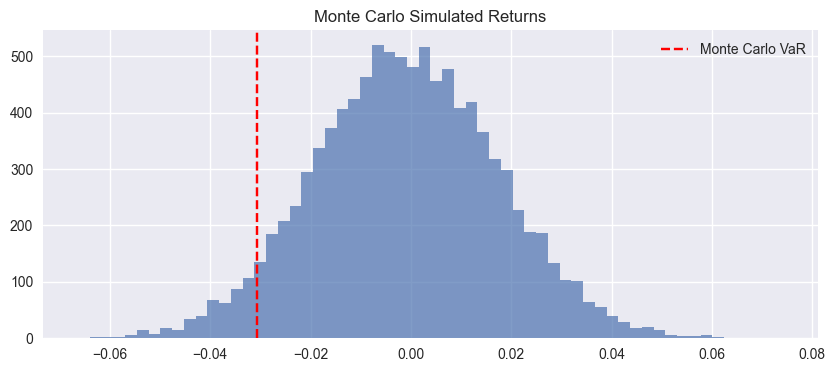

np.float64(-0.03059153191769896)

In [36]:
# Montecarlo VaR
simulated_returns = np.random.normal(
    mean_return,
    std_return,
    mc_sims
)

monte_carlo_var = np.percentile(
    simulated_returns,
    (1 - confidence) * 100
)

plt.figure(figsize=(10,4))
plt.hist(simulated_returns, bins=60, alpha=0.7)
plt.axvline(monte_carlo_var, color="red", linestyle="--", label="Monte Carlo VaR")
plt.title("Monte Carlo Simulated Returns")
plt.legend()
plt.show()

monte_carlo_var


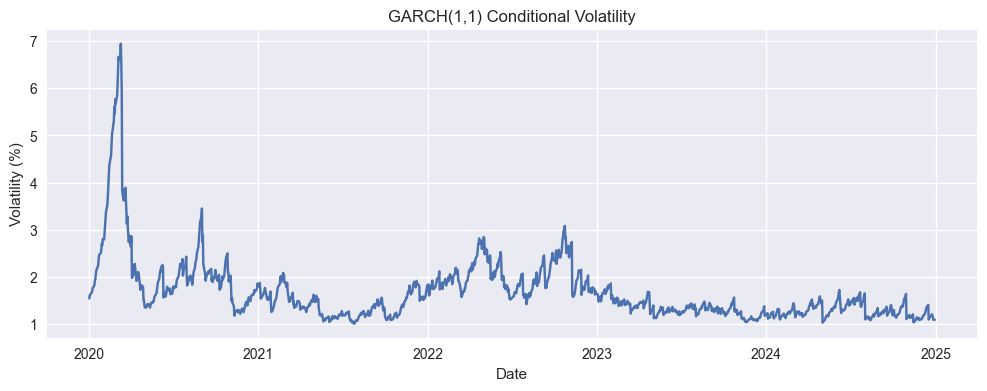

In [37]:
#  Garch(1,1) volatility 
garch = arch_model(
    portfolio_returns * 100,
    vol="Garch",
    p=1,
    q=1,
    dist=garch_dist
)

garch_fit = garch.fit(disp="off")
conditional_vol = garch_fit.conditional_volatility

plt.figure(figsize=(12,4))
plt.plot(conditional_vol)
plt.title("GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.show()


In [38]:
# Garch VaR
forecast = garch_fit.forecast(horizon=1)
sigma = np.sqrt(forecast.variance.iloc[-1, 0])

garch_var = norm.ppf(1 - confidence) * sigma / 100
garch_var


np.float64(-0.025088677297280277)

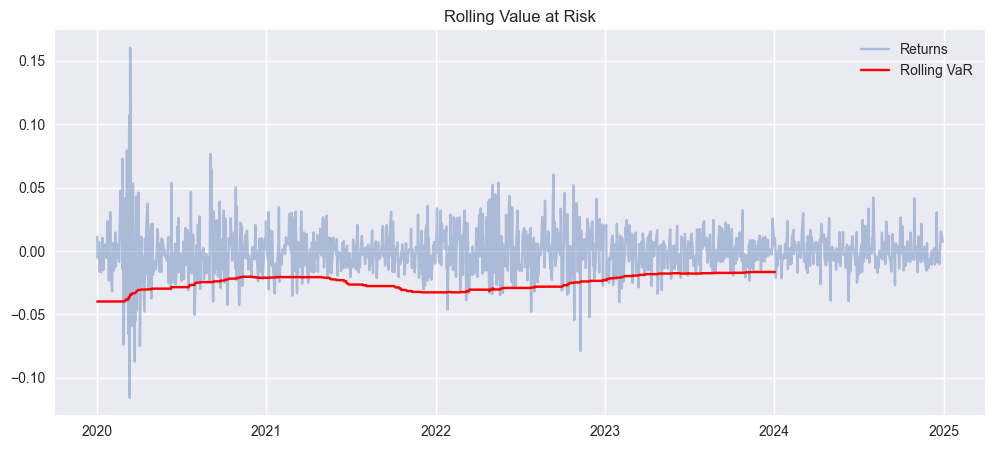

In [39]:
# RollingVaR - Timeseries
rolling_var = portfolio_returns.rolling(
    rolling_window
).quantile(1 - confidence)

plt.figure(figsize=(12,5))
plt.plot(portfolio_returns, alpha=0.4, label="Returns")
plt.plot(rolling_var, color="red", label="Rolling VaR")
plt.title("Rolling Value at Risk")
plt.legend()
plt.show()


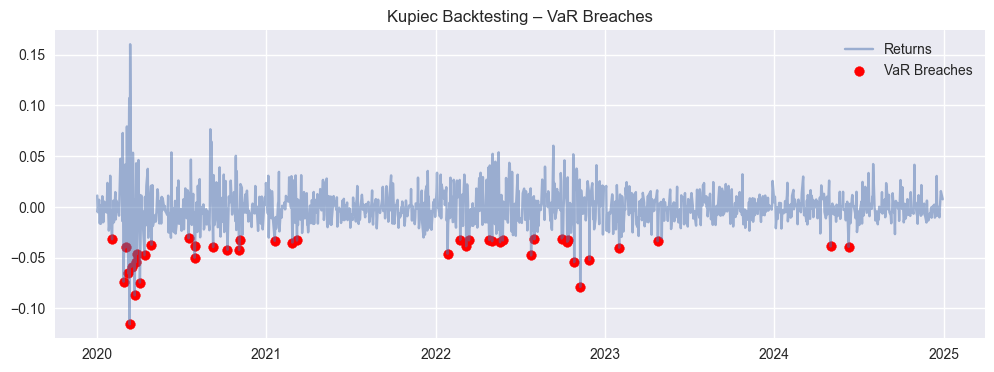

(np.int64(42), np.float64(0.0041818591484624745))

In [40]:
# Kupiec  Backtest - Breach map
def kupiec_test(returns, var_value, confidence):
    breaches = returns < var_value
    x = breaches.sum()
    n = len(returns)
    p = 1 - confidence

    lr = -2 * (
        np.log((1 - p)**(n - x) * p**x) -
        np.log((1 - x/n)**(n - x) * (x/n)**x)
    )

    p_value = 1 - chi2.cdf(lr, df=1)
    return breaches, x, p_value

breaches_series, breaches, p_value = kupiec_test(
    portfolio_returns,
    parametric_var,
    confidence
)

plt.figure(figsize=(12,4))
plt.plot(portfolio_returns, label="Returns", alpha=0.5)
plt.scatter(
    portfolio_returns[breaches_series].index,
    portfolio_returns[breaches_series],
    color="red",
    label="VaR Breaches"
)
plt.title("Kupiec Backtesting – VaR Breaches")
plt.legend()
plt.show()

breaches, p_value


In [41]:
# Basel Test 
if breaches <= 4:
    zone = "GREEN ZONE"
elif breaches <= 9:
    zone = "YELLOW ZONE"
else:
    zone = "RED ZONE"

zone


'RED ZONE'

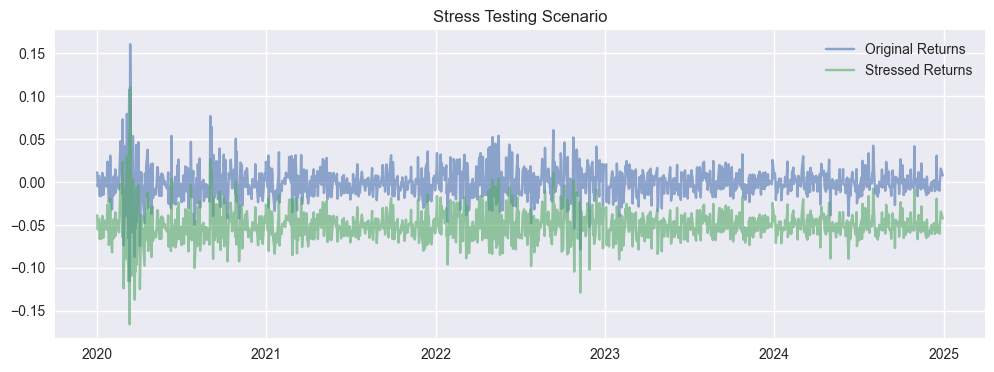

np.float64(-0.07632338286389968)

In [42]:
# Stress testing Before and After
stress_returns = portfolio_returns - stress_shock

plt.figure(figsize=(12,4))
plt.plot(portfolio_returns, label="Original Returns", alpha=0.6)
plt.plot(stress_returns, label="Stressed Returns", alpha=0.6)
plt.title("Stress Testing Scenario")
plt.legend()
plt.show()

stress_var = np.percentile(
    stress_returns,
    (1 - confidence) * 100
)
stress_var
